ARTI406 - Machine Learning  
# Assignment 2: Data Quality Assessment & Preprocessing  
## Dataset: Global Power Plant Database

This notebook completes Assignment 2 using the same dataset used in Assignment 1: the **Global Power Plant Database**.

### Assignment Tasks
1. Identify data quality issues in the dataset.
2. Apply one missing value strategy and explain why.
3. Detect and handle outliers using IQR.
4. Normalize numerical features using both Min-Max and Z-score.
5. Apply PCA and interpret explained variance.


## 1. Import Libraries


In [145]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


## 2. Load Dataset

In [146]:
possible_paths = [
    "/content/sample_data/global_power_plant_database.csv"
]

csv_path = None
for path in possible_paths:
    if os.path.exists(path):
        csv_path = path
# Load the dataset
df_original = pd.read_csv(csv_path)
df = df_original.copy()

print("Shape:", df.shape)
df.head()


Shape: (34936, 36)


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,other_fuel3,commissioning_year,owner,source,url,geolocation_source,wepp_id,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,generation_gwh_2017,generation_gwh_2018,generation_gwh_2019,generation_data_source,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.1190,Hydro,NaN,NaN,NaN,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,1009793,2017.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.7950,Solar,NaN,NaN,NaN,NaN,NaN,Wiki-Solar,https://www.wiki-solar.org,Wiki-Solar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.7920,Solar,NaN,NaN,NaN,NaN,NaN,Wiki-Solar,https://www.wiki-solar.org,Wiki-Solar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.556,69.4787,Hydro,NaN,NaN,NaN,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,1009795,2017.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.641,69.7170,Hydro,NaN,NaN,NaN,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,1009797,2017.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1


## 3.  Dataset Overview

In [147]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())

df.info()


Number of rows: 34936
Number of columns: 36

Column names:
['country', 'country_long', 'name', 'gppd_idnr', 'capacity_mw', 'latitude', 'longitude', 'primary_fuel', 'other_fuel1', 'other_fuel2', 'other_fuel3', 'commissioning_year', 'owner', 'source', 'url', 'geolocation_source', 'wepp_id', 'year_of_capacity_data', 'generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015', 'generation_gwh_2016', 'generation_gwh_2017', 'generation_gwh_2018', 'generation_gwh_2019', 'generation_data_source', 'estimated_generation_gwh_2013', 'estimated_generation_gwh_2014', 'estimated_generation_gwh_2015', 'estimated_generation_gwh_2016', 'estimated_generation_gwh_2017', 'estimated_generation_note_2013', 'estimated_generation_note_2014', 'estimated_generation_note_2015', 'estimated_generation_note_2016', 'estimated_generation_note_2017']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 36 columns):
 #   Column                          Non-Null Count  D

# Task 1 — Identify Data Quality Issues

Data quality issues may include:
- Missing values
- Duplicate records
- Incorrect data types
- Outliers
- Impossible or suspicious values
- Columns with too many missing values


## 4. Missing Values Check
We calculate the number and percentage of missing values in each column.


In [148]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage (%)": (df.isna().mean() * 100).round(2)
}).sort_values(by="Missing Count", ascending=False)

missing_summary[missing_summary["Missing Count"] > 0]


,Missing Count,Missing Percentage (%)
other_fuel3,34844,99.74
other_fuel2,34660,99.21
other_fuel1,32992,94.44
generation_gwh_2013,28519,81.63
generation_gwh_2014,27710,79.32
generation_gwh_2015,26733,76.52
generation_gwh_2016,25792,73.83
generation_gwh_2017,25436,72.81
generation_gwh_2018,25299,72.42
generation_gwh_2019,25277,72.35


## 5. Duplicate Rows Check
Duplicate rows can make analysis biased because the same record is counted more than once.


In [149]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)


Number of duplicate rows: 0


## 6. Data Types Check
We check whether columns are stored with suitable data types.


In [150]:
data_types = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Unique Values": df.nunique(dropna=True).values
})

data_types


,Column,Data Type,Unique Values
0,country,object,167
1,country_long,object,167
2,name,object,34528
3,gppd_idnr,object,34936
4,capacity_mw,float64,5611
5,latitude,float64,31779
6,longitude,float64,33036
7,primary_fuel,object,15
8,other_fuel1,object,12
9,other_fuel2,object,11


## 7.  Statistical Summary

In [151]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,34936,167,USA,9833,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country_long,34936,167,United States of America,9833,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,34936,34528,Santo Antônio,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gppd_idnr,34936,34936,GEODB0003803,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
capacity_mw,34936.0,NaN,NaN,NaN,163.355148,489.636072,1.0,4.9,16.745,75.34425,22500.0
latitude,34936.0,NaN,NaN,NaN,32.816637,22.638603,-77.847,29.256475,39.72775,46.263125,71.292
longitude,34936.0,NaN,NaN,NaN,-6.972803,78.40585,-179.9777,-77.64155,-2.1271,49.502675,179.3887
primary_fuel,34936,15,Solar,10665,NaN,NaN,NaN,NaN,NaN,NaN,NaN
other_fuel1,1944,12,Oil,1169,NaN,NaN,NaN,NaN,NaN,NaN,NaN
other_fuel2,276,11,Gas,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Task 2 — Apply One Missing Value Strategy and Explain Why

### Strategy Used
Columns with more than 500 missing values were removed.  
The remaining missing values were handled using imputation:

- Numerical columns → Median
- Categorical columns → Mode

### Why?
Columns with too many missing values can reduce data quality.  
Median was used because it is less affected by outliers, while mode is suitable for categorical data.

In [152]:
missingBefore = df.isna().sum()

# Remove columns with many missing values

mThres = 500

colsDrop = missingBefore[missingBefore > mThres].index.tolist()

print("Dropped columns:")
print(colsDrop)

df = df.drop(columns=colsDrop)

Dropped columns:
['other_fuel1', 'other_fuel2', 'other_fuel3', 'commissioning_year', 'owner', 'wepp_id', 'year_of_capacity_data', 'generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015', 'generation_gwh_2016', 'generation_gwh_2017', 'generation_gwh_2018', 'generation_gwh_2019', 'generation_data_source', 'estimated_generation_gwh_2013', 'estimated_generation_gwh_2014', 'estimated_generation_gwh_2015', 'estimated_generation_gwh_2016', 'estimated_generation_gwh_2017']


In [153]:
numCols = df.select_dtypes(include=[np.number]).columns
catCols = df.select_dtypes(exclude=[np.number]).columns

#Fill numerical columns with median
for col in numCols:

    if df[col].isna().sum() > 0:

        medianVal = df[col].median()

        df[col] = df[col].fillna(medianVal)

#Fill categorical columns with mode

for col in catCols:

    if df[col].isna().sum() > 0:

        modeVal = df[col].mode()[0]

        df[col] = df[col].fillna(modeVal)


missingAfter = df.isna().sum()

print("\nTotal missing before:", missingBefore.sum())
print("Total missing after:", missingAfter.sum())

# Summary table
missingSummary = pd.DataFrame({
    "Before Missing": missingBefore,
    "After Missing": missingAfter
}).fillna("0")

missingSummary = missingSummary[
    missingSummary["Before Missing"] > 0
].sort_values(by="Before Missing", ascending=False)
missingSummary.dtypes
missingSummary


Total missing before: 455857
Total missing after: 0


,Before Missing,After Missing
other_fuel3,34844,0
other_fuel2,34660,0
other_fuel1,32992,0
generation_gwh_2013,28519,0
generation_gwh_2014,27710,0
generation_gwh_2015,26733,0
generation_gwh_2016,25792,0
generation_gwh_2017,25436,0
generation_gwh_2018,25299,0
generation_gwh_2019,25277,0


# Task 3 — Detect and Handle Outliers Using IQR

In [154]:
Q1 = df['latitude'].quantile(0.25)
Q3 = df['latitude'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['latitude'] < lower) |
    (df['latitude'] > upper)
]

print("Number of outliers:", len(outliers))

outliers.head(8)

Number of outliers: 4159


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,source,url,geolocation_source,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
76,AGO,Angola,Biopio,WRI1023002,22.80,-12.4706,13.7319,Oil,African Development Bank Group,http://powerafrica.opendataforafrica.org,Power Africa,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1
77,AGO,Angola,Biopio (hydro),WRI1023001,14.60,-12.4706,13.7319,Hydro,African Development Bank Group,http://powerafrica.opendataforafrica.org,Power Africa,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
78,AGO,Angola,Cambambe,WRI1023003,180.00,-9.7523,14.4809,Hydro,African Development Bank Group,http://powerafrica.opendataforafrica.org,Power Africa,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
79,AGO,Angola,Capanda,WRI1023004,520.00,-9.7955,15.4672,Hydro,African Development Bank Group,http://powerafrica.opendataforafrica.org,Power Africa,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
80,AGO,Angola,Cazenga,WRI1023005,132.00,-8.8383,13.2344,Gas,African Development Bank Group,http://powerafrica.opendataforafrica.org,Power Africa,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1
81,AGO,Angola,Huambo,WRI1023006,16.26,-12.7600,15.7500,Oil,African Development Bank Group,http://powerafrica.opendataforafrica.org,Power Africa,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1
82,AGO,Angola,Lobito,WRI1023007,20.00,-12.3700,13.5700,Gas,African Development Bank Group,http://powerafrica.opendataforafrica.org,Power Africa,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1
83,AGO,Angola,Luanda Diesel,WRI1023008,58.00,-8.8383,13.2344,Oil,African Development Bank Group,http://powerafrica.opendataforafrica.org,Power Africa,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1


In [155]:
# Remove outliers
dfNoOutliers = df[
    (df['latitude'] >= lower) &
    (df['latitude'] <= upper)
]

print("Original shape:", df.shape)
print("Shape after removing outliers:",
      dfNoOutliers.shape)

Original shape: (34936, 16)
Shape after removing outliers: (30777, 16)


# Task 4 — Normalize Numerical Features Using Min-Max and Z-score

In [156]:
# Min-Max Normalization
from sklearn.preprocessing import MinMaxScaler

# One column for Min-Max
mmScaler = MinMaxScaler()

df['latitude_MinMax'] = mmScaler.fit_transform(
    df[['latitude']]
)

df[['latitude', 'latitude_MinMax']].head()

,latitude,latitude_MinMax
0,32.322,0.738700
1,31.670,0.734328
2,31.623,0.734013
3,34.556,0.753679
4,34.641,0.754249


In [157]:
from sklearn.preprocessing import StandardScaler

# Select two features
dfZScore = df[['latitude', 'longitude']].copy()

# Apply Z-score normalization
zScaler = StandardScaler()

dfZScore[['latitude_ZScore',
          'longitude_ZScore']] = zScaler.fit_transform(
    df[['latitude', 'longitude']]
)

dfZScore.head()

,latitude,longitude,latitude_ZScore,longitude_ZScore
0,32.322,65.1190,-0.021850,0.919483
1,31.670,65.7950,-0.050650,0.928105
2,31.623,65.7920,-0.052726,0.928067
3,34.556,69.4787,0.076833,0.975088
4,34.641,69.7170,0.080588,0.978127


# Task 5 — Apply PCA and Interpret Explained Variance

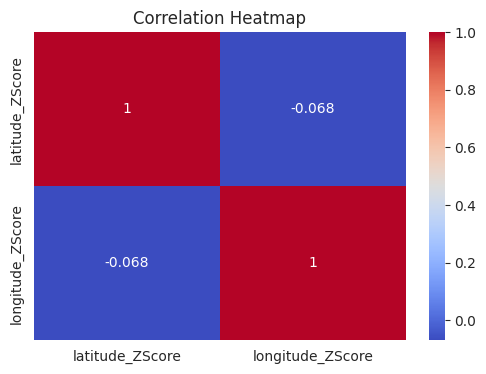

In [158]:
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(6,4))

sns.heatmap(
    dfZScore[['latitude_ZScore',
              'longitude_ZScore']].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [159]:
from sklearn.decomposition import PCA

# Select normalized features
X = dfZScore[['latitude_ZScore',
              'longitude_ZScore']]

# Apply PCA
pca = PCA(n_components=2)

principalComponents = pca.fit_transform(X)

# Explained variance
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.5341772 0.4658228]
